C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2705360495.py:8: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2705360495.py:8: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2705360495.py:9: RuntimeWarning: divide by zero encountered in log
  log_transformed = 1 * (np.log(img + 1))
C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2705360495.py:10: RuntimeWarning: invalid value encountered in cast
  log_transformed = np.array(log_transformed, dtype=np.uint8)


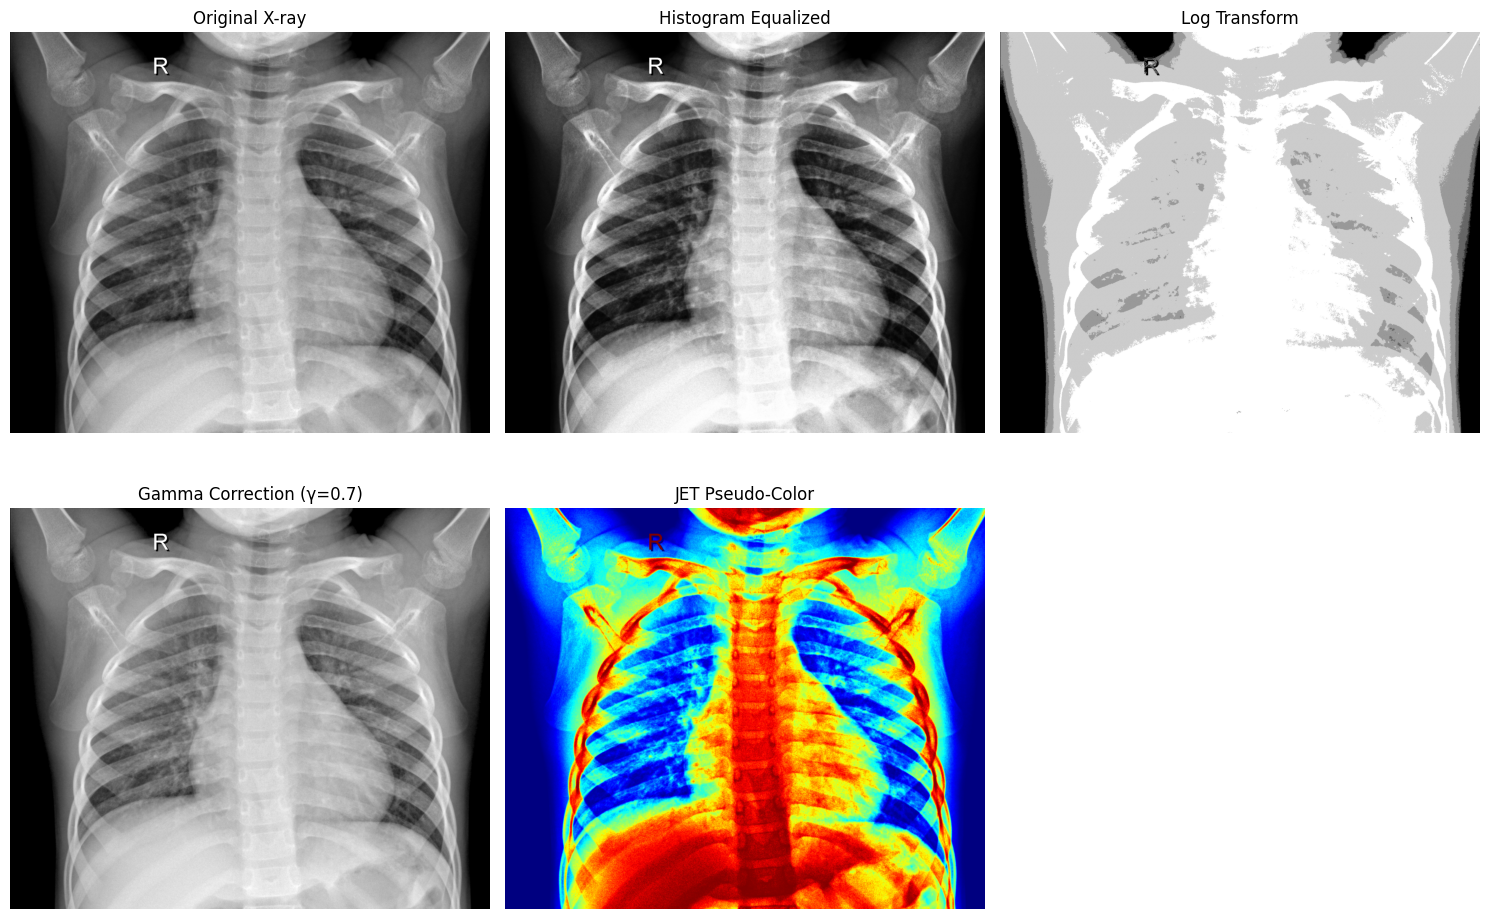

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('img.jpeg', cv2.IMREAD_GRAYSCALE)

hist_eq = cv2.equalizeHist(img)
c = 255 / np.log(1 + np.max(img))
log_transformed = 1 * (np.log(img + 1))
log_transformed = np.array(log_transformed, dtype=np.uint8)

gamma_val = 0.7
gamma_corrected = np.array(255 * (img / 255) ** gamma_val, dtype=np.uint8)
color_heatmap = cv2.applyColorMap(hist_eq, cv2.COLORMAP_JET)
titles = ['Original X-ray', 'Histogram Equalized', 'Log Transform', 
           f'Gamma Correction (γ={gamma_val})', 'JET Pseudo-Color']

images = [img, hist_eq, log_transformed, gamma_corrected, color_heatmap]
plt.figure(figsize=(15, 10))
for i in range(5):
     plt.subplot(2, 3, i+1)
     if i == 4:  
         plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
     else:
         plt.imshow(images[i], cmap='gray')
     plt.title(titles[i])
     plt.axis('off')
plt.tight_layout()
plt.show()

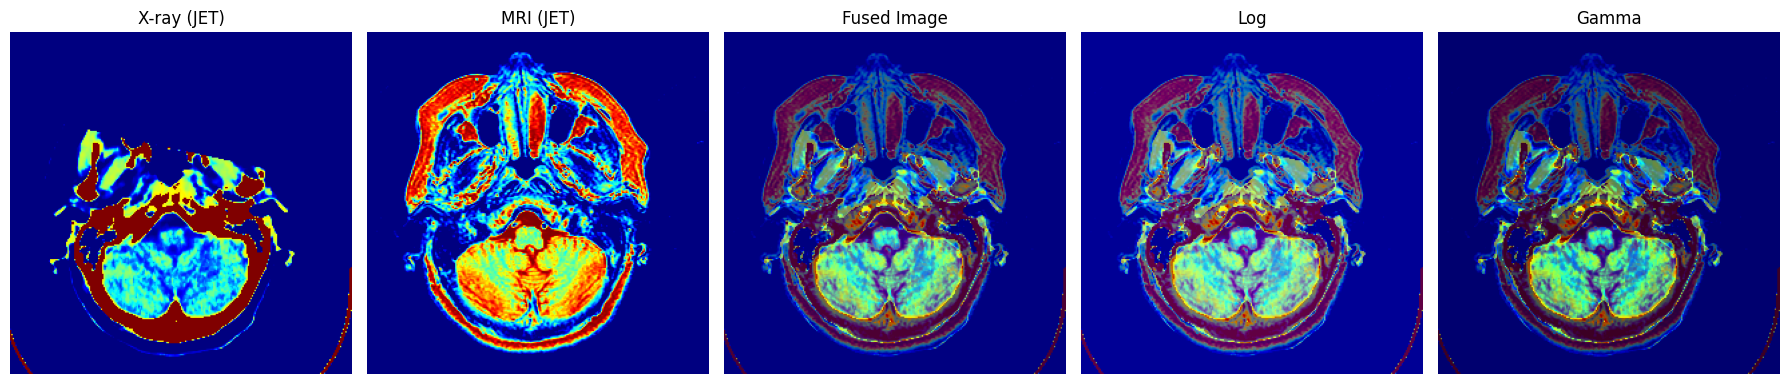

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

xray = cv2.imread('CT.png', cv2.IMREAD_GRAYSCALE)
mri = cv2.imread('MRI.png', cv2.IMREAD_GRAYSCALE)

if xray is None or mri is None:
    print("Error")
else:
    if xray.shape != mri.shape:
        mri = cv2.resize(mri, (xray.shape[1], xray.shape[0]))

    xray_eq = cv2.equalizeHist(xray)
    mri_eq = cv2.equalizeHist(mri)

    xray_color = cv2.applyColorMap(xray_eq, cv2.COLORMAP_JET)
    mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)

    alpha = 0.6  
    fused = cv2.addWeighted(xray_color, alpha, mri_color, (1 - alpha), 0)

    fused_norm = fused.astype(np.float32) / 255.0
    
    c = 1.0 / np.log(1 + 1.0)
    fused_log = c * np.log(1 + fused_norm)
    fused_log = np.clip(fused_log * 255, 0, 255).astype(np.uint8)
    
    gamma = 1.2
    fused_gamma = np.power(fused_norm, gamma)
    fused_gamma = np.clip(fused_gamma * 255, 0, 255).astype(np.uint8)

    titles = ['X-ray (JET)', 'MRI (JET)', 'Fused Image', 'Log', 'Gamma']
    images = [xray_color, mri_color, fused, fused_log, fused_gamma]

    plt.figure(figsize=(18, 8))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

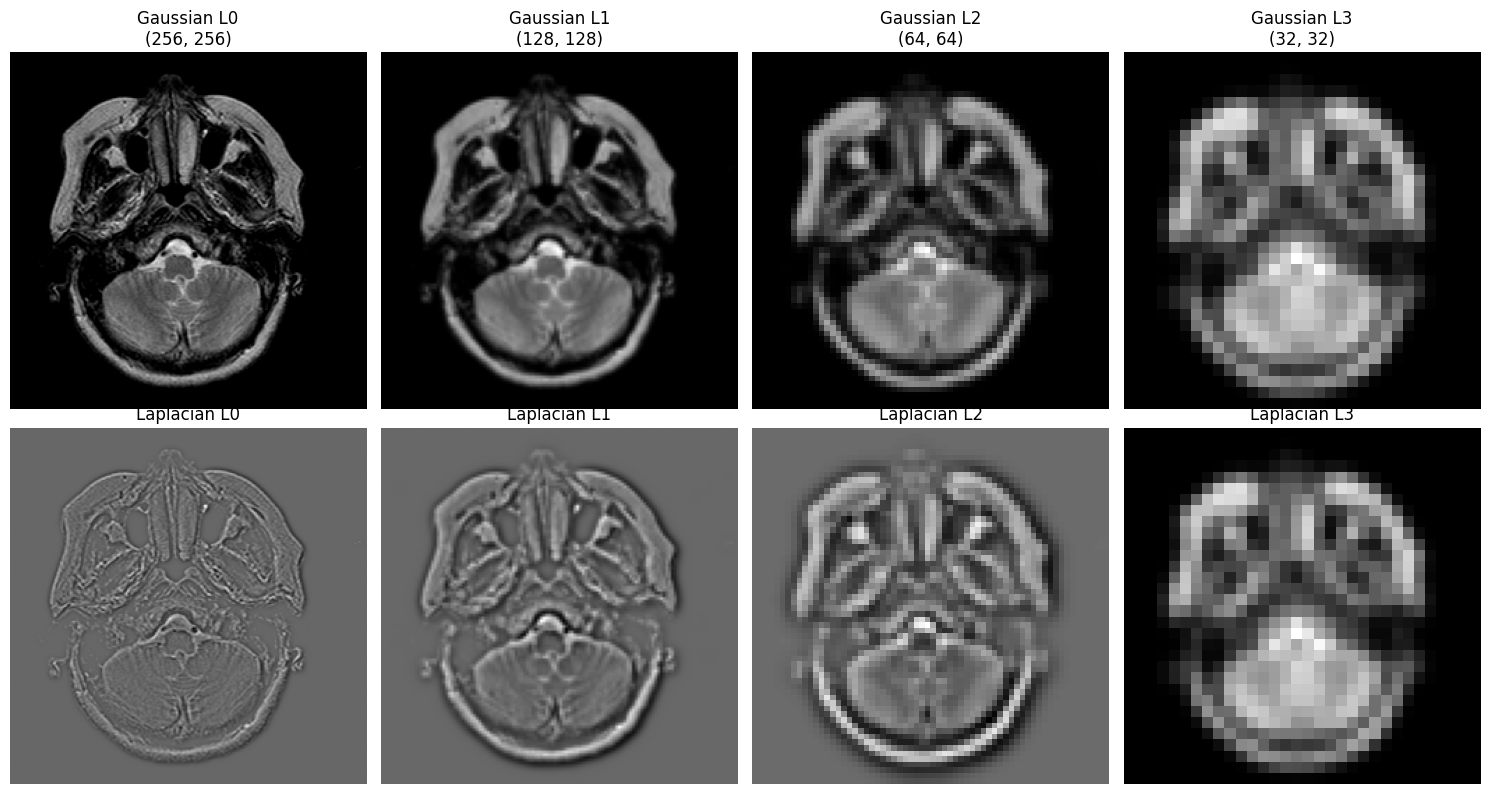

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def manual_downsample(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    return blurred[::2, ::2]

def manual_upsample_bilinear(image, target_shape):
    height, width = target_shape[:2]
    old_h, old_w = image.shape[:2]
    
    new_h = np.linspace(0, old_h - 1, height)
    new_w = np.linspace(0, old_w - 1, width)
    result = np.zeros((height, width), dtype=np.float32)
    
    for i in range(height):
        for j in range(width):
            y, x = new_h[i], new_w[j]
            y0, x0 = int(np.floor(y)), int(np.floor(x))
            y1, x1 = min(y0 + 1, old_h - 1), min(x0 + 1, old_w - 1)
            
            wa = (x1 - x) * (y1 - y)
            wb = (x - x0) * (y1 - y)
            wc = (x1 - x) * (y - y0)
            wd = (x - x0) * (y - y0)
            
            result[i, j] = (wa * image[y0, x0] + wb * image[y0, x1] + wc * image[y1, x0] + wd * image[y1, x1])
            
    return cv2.GaussianBlur(result, (5, 5), 0)


img = cv2.imread('MRI.png', cv2.IMREAD_GRAYSCALE)

gaussian_pyramid = [img.astype(np.float32)]
for i in range(3):
    down = manual_downsample(gaussian_pyramid[i])
    gaussian_pyramid.append(down)

laplacian_pyramid = []
for i in range(3):
    upsampled = manual_upsample_bilinear(gaussian_pyramid[i+1], gaussian_pyramid[i].shape)
    laplacian = cv2.subtract(gaussian_pyramid[i], upsampled)
    laplacian_pyramid.append(laplacian)

laplacian_pyramid.append(gaussian_pyramid[-1])

plt.figure(figsize=(15, 8))
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(gaussian_pyramid[i], cmap='gray')
    plt.title(f'Gaussian L{i}\n{gaussian_pyramid[i].shape}')
    plt.axis('off')

for i in range(4):
    plt.subplot(2, 4, i+5)
    plt.imshow(laplacian_pyramid[i], cmap='gray')
    plt.title(f'Laplacian L{i}')
    plt.axis('off')

plt.tight_layout()
plt.show()

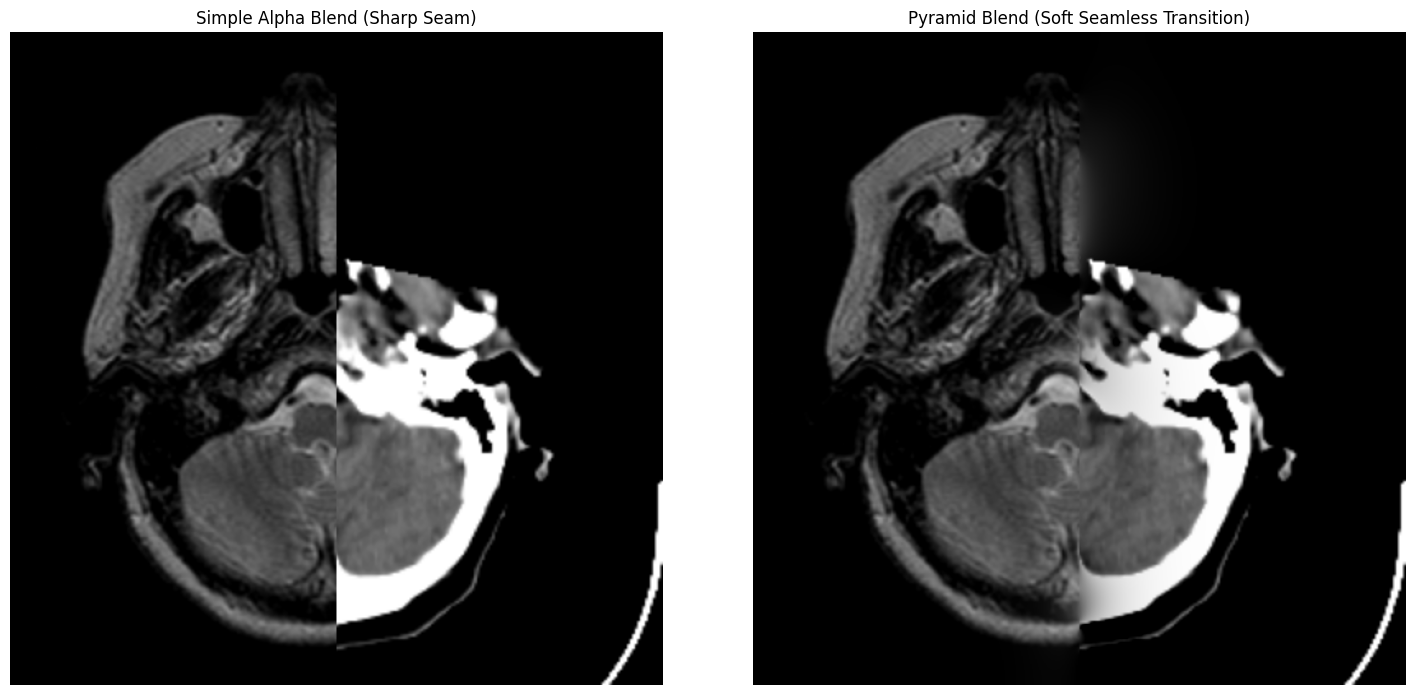

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_gaussian_pyramid(img, levels=6): 
    gp = [img.astype(np.float32)]
    for i in range(levels - 1):
        blurred = cv2.GaussianBlur(gp[i], (11, 11), 0) 
        down = blurred[::2, ::2]
        gp.append(down)
    return gp

def get_laplacian_pyramid(gp):
    lp = []
    for i in range(len(gp) - 1):
        upsampled = cv2.resize(gp[i+1], (gp[i].shape[1], gp[i].shape[0]))
        lp.append(cv2.subtract(gp[i], upsampled))
    lp.append(gp[-1])
    return lp

img_a = cv2.imread('MRI.png').astype(np.float32)
img_b = cv2.imread('CT.png').astype(np.float32)

size = (512, 512)
img_a = cv2.resize(img_a, size)
img_b = cv2.resize(img_b, size)

mask = np.zeros(img_a.shape[:2], dtype=np.float32)
mask[:, :img_a.shape[1]//2] = 1.0 

levels = 6
gp_a = get_gaussian_pyramid(img_a, levels)
lp_a = get_laplacian_pyramid(gp_a)

gp_b = get_gaussian_pyramid(img_b, levels)
lp_b = get_laplacian_pyramid(gp_b)

gp_mask = get_gaussian_pyramid(mask, levels)
blended_lp = []
for i in range(len(lp_a)):
    m = cv2.merge([gp_mask[i]] * 3) if len(img_a.shape) == 3 else gp_mask[i]
    blended_level = m * lp_a[i] + (1.0 - m) * lp_b[i]
    blended_lp.append(blended_level)
reconstructed = blended_lp[-1]
for i in range(len(blended_lp) - 2, -1, -1):
    upsampled = cv2.resize(reconstructed, (blended_lp[i].shape[1], blended_lp[i].shape[0]))
    reconstructed = cv2.add(upsampled, blended_lp[i])
mask_3ch = cv2.merge([mask] * 3)
alpha_blend = mask_3ch * img_a + (1.0 - mask_3ch) * img_b

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(np.clip(alpha_blend, 0, 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title("Simple Alpha Blend (Sharp Seam)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(np.clip(reconstructed, 0, 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title("Pyramid Blend (Soft Seamless Transition)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [28]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not cap.isOpened():
    print("Error: Could not access the webcam.")
else:
    print("Press 'q' to stop the video feed.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    equalized = cv2.equalizeHist(gray)
    heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
    c_log = 255 / np.log(1 + np.max(gray)) if np.max(gray) > 0 else 0
    log_transformed = (1 * (np.log(gray + 1))).astype(np.uint8)
    log_display = cv2.cvtColor(log_transformed, cv2.COLOR_GRAY2BGR)
    gamma = 0.6
    gamma_corrected = np.array(255 * (gray / 255) ** gamma, dtype=np.uint8)
    gamma_display = cv2.cvtColor(gamma_corrected, cv2.COLOR_GRAY2BGR)
    top_row = np.hstack((frame, gamma_display))
    bottom_row = np.hstack((log_display, heatmap))
    combined_view = np.vstack((top_row, bottom_row))
    display_resized = cv2.resize(combined_view, (960, 720))
    cv2.imshow('Real-Time Enhancement Comparison', display_resized)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press 'q' to stop the video feed.


C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2333860125.py:21: RuntimeWarning: overflow encountered in scalar add
  c_log = 255 / np.log(1 + np.max(gray)) if np.max(gray) > 0 else 0
C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2333860125.py:21: RuntimeWarning: divide by zero encountered in log
  c_log = 255 / np.log(1 + np.max(gray)) if np.max(gray) > 0 else 0
C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2333860125.py:22: RuntimeWarning: divide by zero encountered in log
  log_transformed = (1 * (np.log(gray + 1))).astype(np.uint8)
C:\Users\Hashir\AppData\Local\Temp\ipykernel_10644\2333860125.py:22: RuntimeWarning: invalid value encountered in cast
  log_transformed = (1 * (np.log(gray + 1))).astype(np.uint8)
